In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


c:\Users\allur\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
file_path = "../data/processed/feature_engineered_ev_dataset.csv"
master_df = pd.read_csv(file_path)

In [3]:
features = ["ev_stock_lag1", "ev_stock_share_lag1", "charging_points_lag1"]
target = "ev_sales_share"

In [5]:
# CREATE SHAP MODELLING DATAFRAME
shap_df = master_df[
    ["country", "year", "ev_stock_lag1", "ev_stock_share_lag1", "charging_points_lag1", "ev_sales_share"]
].dropna().copy()

# Keep the same ordering used in the final XGBoost model
shap_df = shap_df.sort_values(["year", "country"]).reset_index(drop=True)

print("SHAP modelling dataset shape:")
print(shap_df.shape)
print("\nMissing values:")
print(shap_df.isnull().sum())
print("\nYears available:")
print(sorted(shap_df["year"].unique()))

SHAP modelling dataset shape:
(499, 6)

Missing values:
country                 0
year                    0
ev_stock_lag1           0
ev_stock_share_lag1     0
charging_points_lag1    0
ev_sales_share          0
dtype: int64

Years available:
[np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [6]:
# CREATE TIME-BASED TRAIN / TEST SPLIT
shap_train_df = shap_df[shap_df["year"] <= 2022].copy()
shap_test_df = shap_df[shap_df["year"].isin([2023, 2024])].copy()

print("\nTraining dataset shape:")
print(shap_train_df.shape)
print("\nTesting dataset shape:")
print(shap_test_df.shape)


Training dataset shape:
(421, 6)

Testing dataset shape:
(78, 6)


In [7]:
# CREATE TRAINING AND TEST VARIABLES
X_train = shap_train_df[features]
y_train = shap_train_df[target]

X_test = shap_test_df[features]
y_test = shap_test_df[target]

print("\nX_train shape:")
print(X_train.shape)
print("\nX_test shape:")
print(X_test.shape)


X_train shape:
(421, 3)

X_test shape:
(78, 3)


In [8]:
# RECREATE FINAL TUNED XGBOOST MODEL
final_xgb_model = XGBRegressor(
    colsample_bytree=1.0,
    learning_rate=0.05,
    max_depth=5,
    n_estimators=300,
    subsample=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=1
)

# TRAIN FINAL XGBOOST MODEL
final_xgb_model.fit(X_train, y_train)

# VERIFY FINAL MODEL PERFORMANCE
y_pred = final_xgb_model.predict(X_test)

final_r2 = r2_score(y_test, y_pred)
final_mae = mean_absolute_error(y_test, y_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nFinal XGBoost Performance Verification")
print(f"R²   : {final_r2:.4f}")
print(f"MAE  : {final_mae:.4f}")
print(f"RMSE : {final_rmse:.4f}")


Final XGBoost Performance Verification
R²   : 0.7491
MAE  : 7.4568
RMSE : 10.3212


In [9]:
# CREATE SHAP EXPLAINER
explainer = shap.TreeExplainer(final_xgb_model)

# CALCULATE SHAP VALUES FOR TEST DATA
shap_values = explainer(X_test)

print("\nSHAP values shape:")
print(shap_values.values.shape)
print("\nSHAP base value:")
print(shap_values.base_values[0])


SHAP values shape:
(78, 3)

SHAP base value:
4.9082146


In [10]:
# VERIFY SHAP ADDITIVE PROPERTY
shap_prediction_check = shap_values.base_values + shap_values.values.sum(axis=1)

shap_verification_df = pd.DataFrame({
    "Model_Prediction": y_pred,
    "SHAP_Reconstructed_Prediction": shap_prediction_check,
    "Difference": y_pred - shap_prediction_check
})

print("\nSHAP Prediction Reconstruction Check:")
print(shap_verification_df.head(10))
print("\nMaximum SHAP Reconstruction Difference:")
print(np.abs(shap_verification_df["Difference"]).max())


SHAP Prediction Reconstruction Check:
   Model_Prediction  SHAP_Reconstructed_Prediction    Difference
0          6.193113                       6.193113 -4.768372e-07
1         29.085255                      29.085266 -1.144409e-05
2         36.700108                      36.700092  1.525879e-05
3          2.202327                       2.202327  0.000000e+00
4         18.886566                      18.886559  7.629395e-06
5          1.090266                       1.090265  1.311302e-06
6         46.385662                      46.385643  1.907349e-05
7          4.057763                       4.057761  1.907349e-06
8          4.932558                       4.932557  9.536743e-07
9         61.731316                      61.731350 -3.433228e-05

Maximum SHAP Reconstruction Difference:
0.00010681152


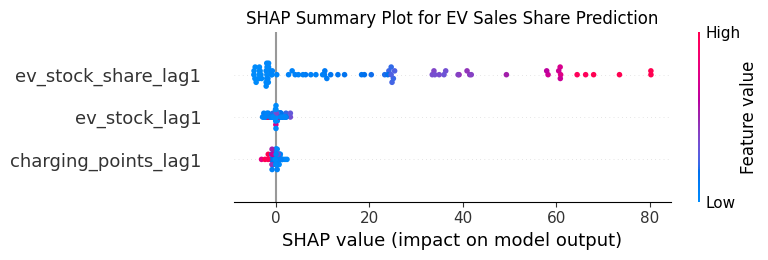

In [11]:
# SHAP SUMMARY BEESWARM PLOT
shap.summary_plot(shap_values.values, X_test, feature_names=features, show=False)
plt.title("SHAP Summary Plot for EV Sales Share Prediction")
plt.tight_layout()
plt.show()

In [12]:
# CALCULATE MEAN ABSOLUTE SHAP VALUES
mean_absolute_shap = np.abs(shap_values.values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Feature": features,
    "Mean_Absolute_SHAP": mean_absolute_shap
})
shap_importance_df = shap_importance_df.sort_values(
    "Mean_Absolute_SHAP", ascending=False
).reset_index(drop=True)

print("\nMean Absolute SHAP Feature Importance:")
print(shap_importance_df)


Mean Absolute SHAP Feature Importance:
                Feature  Mean_Absolute_SHAP
0   ev_stock_share_lag1           21.830763
1         ev_stock_lag1            1.024542
2  charging_points_lag1            0.625796


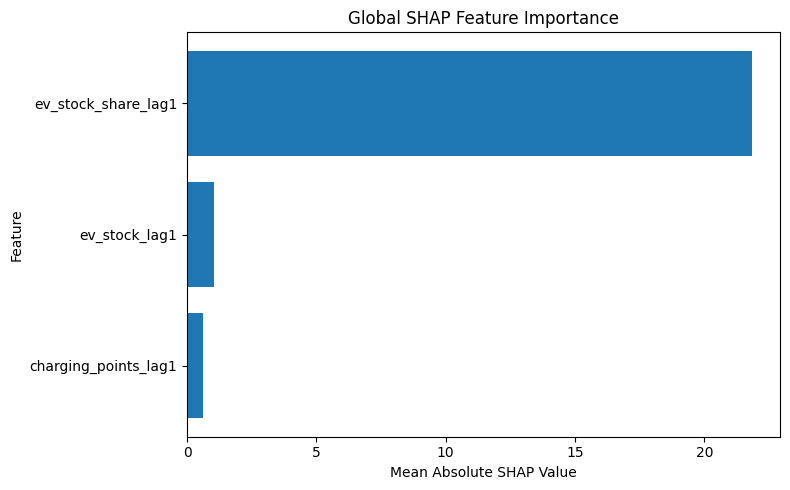

In [13]:
# MEAN ABSOLUTE SHAP IMPORTANCE PLOT
plt.figure(figsize=(8, 5))
plt.barh(shap_importance_df["Feature"], shap_importance_df["Mean_Absolute_SHAP"])
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Global SHAP Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

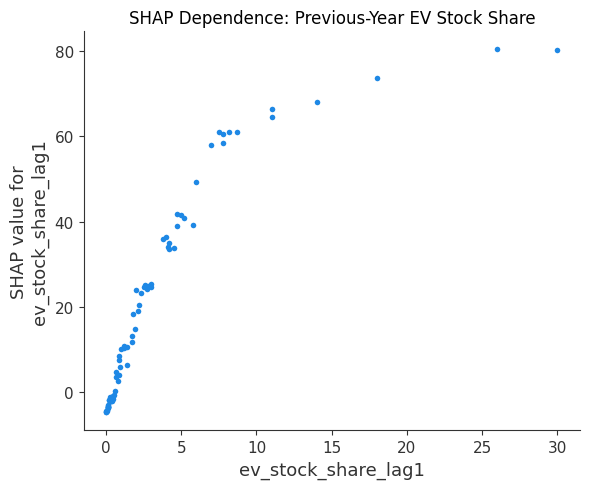

In [14]:
# SHAP DEPENDENCE PLOT: PREVIOUS-YEAR EV STOCK SHARE
shap.dependence_plot("ev_stock_share_lag1", shap_values.values, X_test, interaction_index=None, show=False)
plt.title("SHAP Dependence: Previous-Year EV Stock Share")
plt.tight_layout()
plt.show()

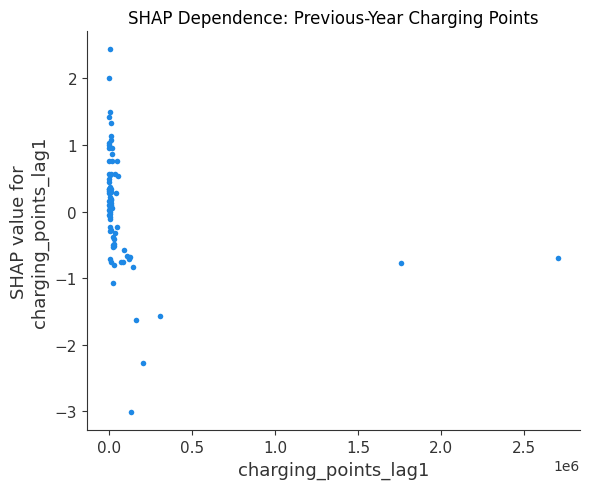

In [15]:
# SHAP DEPENDENCE PLOT: PREVIOUS-YEAR CHARGING POINTS
shap.dependence_plot("charging_points_lag1", shap_values.values, X_test, interaction_index=None, show=False)
plt.title("SHAP Dependence: Previous-Year Charging Points")
plt.tight_layout()
plt.show()

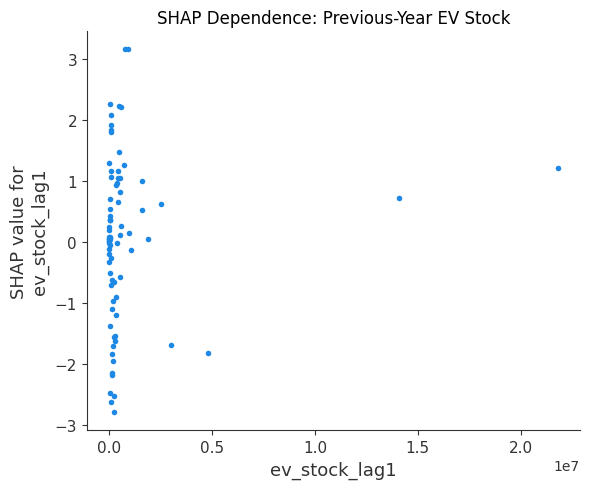

In [16]:
# SHAP DEPENDENCE PLOT: PREVIOUS-YEAR EV STOCK
shap.dependence_plot("ev_stock_lag1", shap_values.values, X_test, interaction_index=None, show=False)
plt.title("SHAP Dependence: Previous-Year EV Stock")
plt.tight_layout()
plt.show()

In [17]:
# CREATE TEST EXPLANATION DATAFRAME
shap_results_df = shap_test_df[["country", "year"]].copy()
shap_results_df["actual_ev_sales_share"] = y_test.values
shap_results_df["predicted_ev_sales_share"] = y_pred
shap_results_df["absolute_error"] = np.abs(y_test.values - y_pred)

for feature_index, feature_name in enumerate(features):
    shap_results_df[f"{feature_name}_shap"] = shap_values.values[:, feature_index]

print("\nSHAP Test Results:")
print(shap_results_df.head(10))


SHAP Test Results:
        country  year  actual_ev_sales_share  predicted_ev_sales_share  \
421   Australia  2023                  12.00                  6.193113   
422     Austria  2023                  27.00                 29.085255   
423     Belgium  2023                  41.00                 36.700108   
424      Brazil  2023                   3.00                  2.202327   
425      Canada  2023                  13.00                 18.886566   
426       Chile  2023                   0.75                  1.090266   
427       China  2023                  38.00                 46.385662   
428    Colombia  2023                   3.90                  4.057763   
429  Costa Rica  2023                  13.00                  4.932558   
430     Denmark  2023                  46.00                 61.731316   

     absolute_error  ev_stock_lag1_shap  ev_stock_share_lag1_shap  \
421        5.806887            1.157287                  0.247008   
422        2.085255        


Observation with Largest Prediction Error:
country                        Iceland
year                              2024
actual_ev_sales_share             42.0
predicted_ev_sales_share     76.055984
absolute_error               34.055984
ev_stock_lag1_shap           -2.470328
ev_stock_share_lag1_shap      73.56115
charging_points_lag1_shap     0.056998
Name: 474, dtype: object


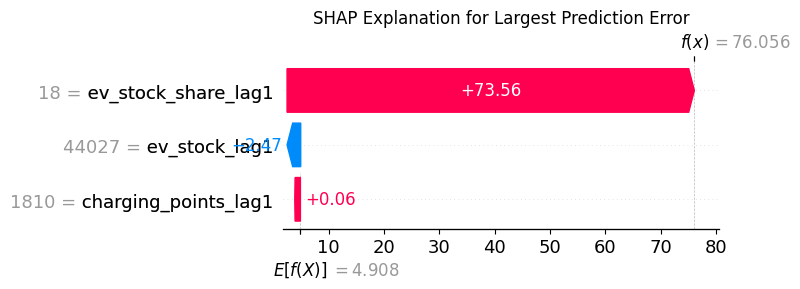

In [18]:
# IDENTIFY LARGEST PREDICTION ERROR
largest_error_index = shap_results_df["absolute_error"].idxmax()
largest_error_position = shap_results_df.index.get_loc(largest_error_index)
largest_error_row = shap_results_df.loc[largest_error_index]

print("\nObservation with Largest Prediction Error:")
print(largest_error_row)

# SHAP WATERFALL PLOT: LARGEST PREDICTION ERROR
shap.plots.waterfall(shap_values[largest_error_position], max_display=3, show=False)
plt.title("SHAP Explanation for Largest Prediction Error")
plt.tight_layout()
plt.show()


Observation with Smallest Prediction Error:
country                      South Africa
year                                 2024
actual_ev_sales_share                0.61
predicted_ev_sales_share         0.601173
absolute_error                   0.008827
ev_stock_lag1_shap              -0.027083
ev_stock_share_lag1_shap        -4.376493
charging_points_lag1_shap        0.096536
Name: 490, dtype: object


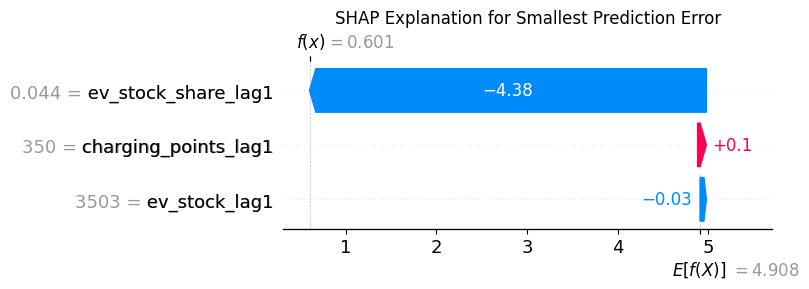

In [19]:
# IDENTIFY BEST PREDICTION
best_prediction_index = shap_results_df["absolute_error"].idxmin()
best_prediction_position = shap_results_df.index.get_loc(best_prediction_index)
best_prediction_row = shap_results_df.loc[best_prediction_index]

print("\nObservation with Smallest Prediction Error:")
print(best_prediction_row)

# SHAP WATERFALL PLOT: BEST PREDICTION
shap.plots.waterfall(shap_values[best_prediction_position], max_display=3, show=False)
plt.title("SHAP Explanation for Smallest Prediction Error")
plt.tight_layout()
plt.show()

In [20]:
# COMPARE SHAP IMPORTANCE WITH XGBOOST BUILT-IN FEATURE IMPORTANCE
xgb_builtin_importance_df = pd.DataFrame({
    "Feature": features,
    "XGBoost_Importance": final_xgb_model.feature_importances_
})

importance_comparison_df = pd.merge(shap_importance_df, xgb_builtin_importance_df, on="Feature")
importance_comparison_df = importance_comparison_df.sort_values(
    "Mean_Absolute_SHAP", ascending=False
).reset_index(drop=True)

print("\nSHAP vs XGBoost Built-in Feature Importance:")
print(importance_comparison_df)


SHAP vs XGBoost Built-in Feature Importance:
                Feature  Mean_Absolute_SHAP  XGBoost_Importance
0   ev_stock_share_lag1           21.830763            0.956865
1         ev_stock_lag1            1.024542            0.020277
2  charging_points_lag1            0.625796            0.022859
